In [2]:
import os

import pandas as pd
import matplotlib.pyplot as plt

from venn import venn4

In [3]:
folder = "./results/excel/"
list_df = []
for file in os.listdir(folder):
    if 'xlsx' in file:
        df = pd.read_excel(f'{folder}/{file}')
        file_name = file[:-5]
        split = file_name.split("_")
        contrast = "_".join(split[1:])
        df['contrast'] = contrast
        list_df+=[df]

In [4]:
concat = pd.concat(list_df)

In [5]:
concat.head()

,gene_id,gene_name,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,contrast
0,ENSMUSG00000000001,Gnai3,6614.435806,0.075209,0.061089,1.231144,0.218269,0.580599,Control_Old_VS_Control_Young
1,ENSMUSG00000000028,Cdc45,2677.765983,-0.051782,0.067684,-0.765054,0.444239,0.783214,Control_Old_VS_Control_Young
2,ENSMUSG00000000031,H19,3.545939,0.109243,0.764630,0.142870,0.886393,0.972519,Control_Old_VS_Control_Young
3,ENSMUSG00000000037,Scml2,506.453130,-0.380693,0.134515,-2.830115,0.004653,0.058260,Control_Old_VS_Control_Young
4,ENSMUSG00000000056,Narf,2833.805782,0.078905,0.161130,0.489696,0.624349,0.885232,Control_Old_VS_Control_Young


In [6]:
concat['contrast'].unique()

array(['Control_Old_VS_Control_Young', 'Trained_Old_VS_Control_Old',
       'Trained_Old_VS_Trained_Young', 'Trained_Young_VS_Control_Young'],
      dtype=object)

<Figure size 800x800 with 0 Axes>

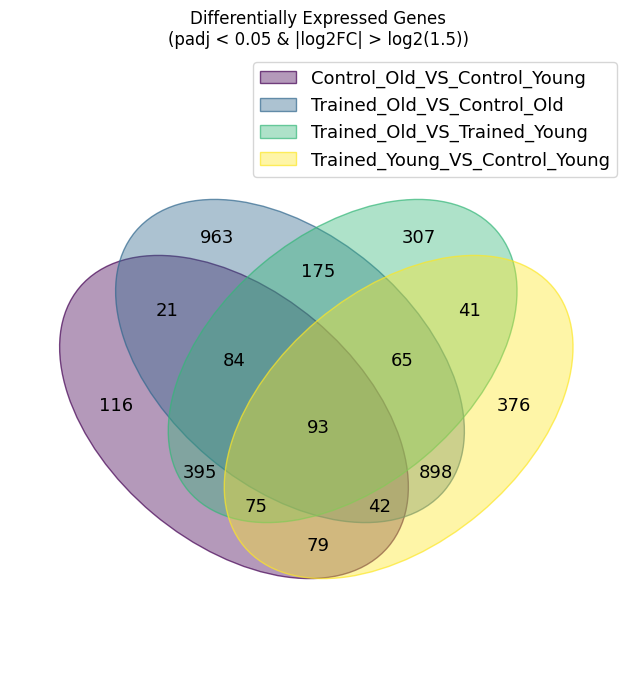

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from venn import venn

# Load your DESeq2-like results
# df = pd.read_csv("your_results.tsv", sep="\t")

# For clarity, assume df already exists
# Columns needed:
# gene_id, gene_name, log2FoldChange, padj, contrast

# Thresholds
padj_threshold = 0.05
log2fc_threshold = np.log2(1.5)  # ~0.585

# Filter DE genes
de_df = concat[
    (concat["padj"] < padj_threshold) &
    (concat["log2FoldChange"].abs() > log2fc_threshold)
]

# Build gene sets per contrast
gene_sets = {
    contrast: set(sub["gene_name"])
    for contrast, sub in de_df.groupby("contrast")
}

# Optional: keep only 4 contrasts (required for a 4-way Venn)
# Adjust this selection if needed
selected_contrasts = list(gene_sets.keys())[:4]
gene_sets_4 = {k: gene_sets[k] for k in selected_contrasts}

# Plot Venn diagram
plt.figure(figsize=(8, 8))
venn(gene_sets_4)
plt.title("Differentially Expressed Genes\n(padj < 0.05 & |log2FC| > log2(1.5))")
plt.show()


<Figure size 600x600 with 0 Axes>

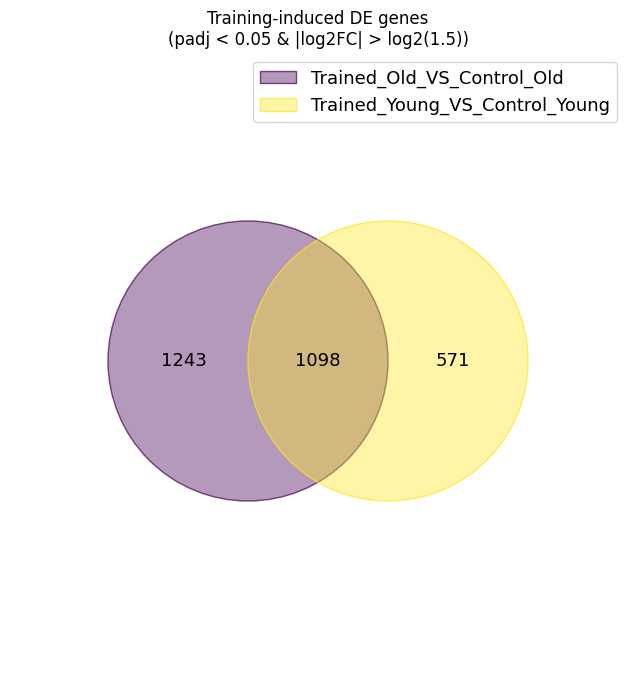

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from venn import venn

# Thresholds
padj_threshold = 0.05
log2fc_threshold = np.log2(1.5)

# Contrasts of interest
contrasts = [
    "Trained_Old_VS_Control_Old",
    "Trained_Young_VS_Control_Young"
]

# Filter DE genes for these contrasts
de = concat[
    (concat["contrast"].isin(contrasts)) &
    (concat["padj"] < padj_threshold) &
    (concat["log2FoldChange"].abs() > log2fc_threshold)
]

# Build gene sets
gene_sets = {
    contrast: set(de.loc[de["contrast"] == contrast, "gene_name"])
    for contrast in contrasts
}

# Plot Venn diagram
plt.figure(figsize=(6, 6))
venn(gene_sets)
plt.title("Training-induced DE genes\n(padj < 0.05 & |log2FC| > log2(1.5))")
plt.show()


### Venn UP

<Figure size 600x600 with 0 Axes>

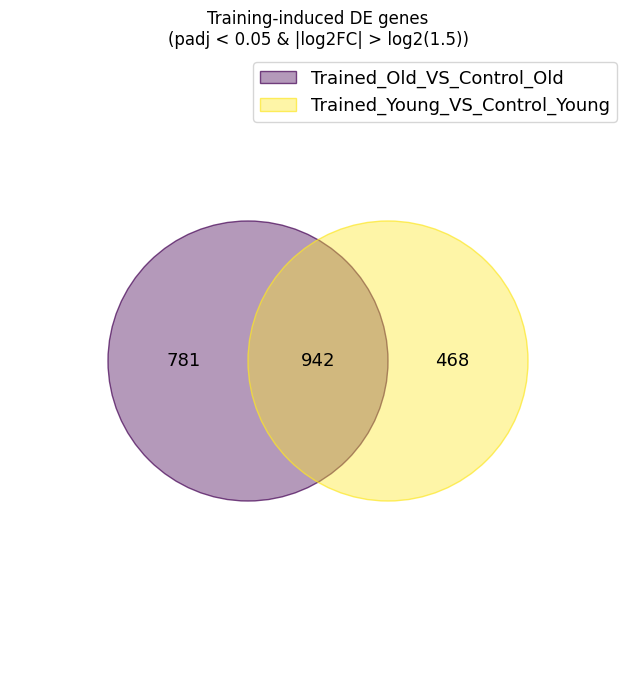

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from venn import venn

# Thresholds
padj_threshold = 0.05
log2fc_threshold = np.log2(1.5)

# Contrasts of interest
contrasts = [
    "Trained_Old_VS_Control_Old",
    "Trained_Young_VS_Control_Young"
]

# Filter DE genes for these contrasts
de = concat[
    (concat["contrast"].isin(contrasts)) &
    (concat["padj"] < padj_threshold) &
    (concat["log2FoldChange"] > log2fc_threshold)
]

# Build gene sets
gene_sets = {
    contrast: set(de.loc[de["contrast"] == contrast, "gene_name"])
    for contrast in contrasts
}

# Plot Venn diagram
plt.figure(figsize=(6, 6))
venn(gene_sets)
plt.title("Training-induced DE genes\n(padj < 0.05 & |log2FC| > log2(1.5))")
plt.show()


<Figure size 600x600 with 0 Axes>

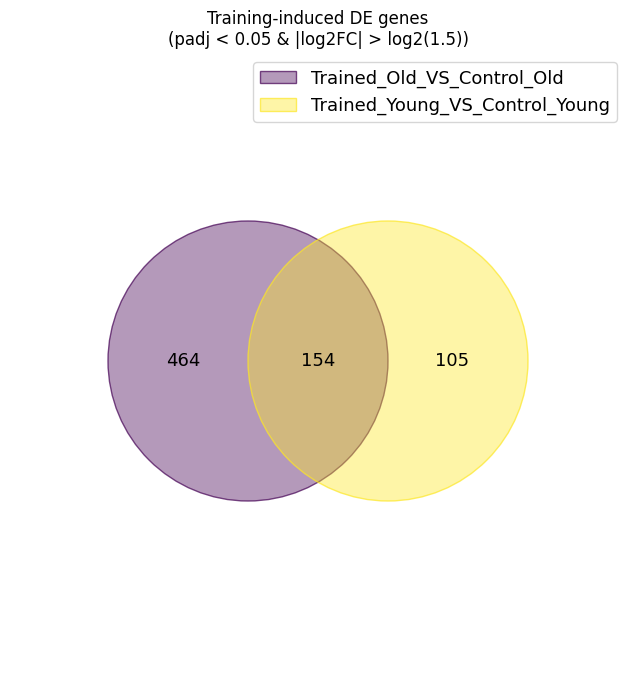

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from venn import venn

# Thresholds
padj_threshold = 0.05
log2fc_threshold = np.log2(1.5)

# Contrasts of interest
contrasts = [
    "Trained_Old_VS_Control_Old",
    "Trained_Young_VS_Control_Young"
]

# Filter DE genes for these contrasts
de = concat[
    (concat["contrast"].isin(contrasts)) &
    (concat["padj"] < padj_threshold) &
    (concat["log2FoldChange"] < -log2fc_threshold)
]

# Build gene sets
gene_sets = {
    contrast: set(de.loc[de["contrast"] == contrast, "gene_name"])
    for contrast in contrasts
}

# Plot Venn diagram
plt.figure(figsize=(6, 6))
venn(gene_sets)
plt.title("Training-induced DE genes\n(padj < 0.05 & |log2FC| > log2(1.5))")
plt.show()